<a href="https://colab.research.google.com/github/tonycuenca99-hue/ARQUIVOS-IA/blob/main/APRENDIZADO_AULA_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
#upload do arquivo
uploaded=files.upload()

Saving iiot_30min_norm.csv to iiot_30min_norm.csv


In [ ]:
#load data
filename=list(uploaded.keys())[0]
df=pd.read_csv(filename)

In [ ]:
#remover coluna citation

In [ ]:
#listar as variavel numericas e categoricas
numeric_vars=df.select_dtypes(include=[np.number]).columns
categorical_vars=df.select_dtypes(include=["object"]).columns

In [ ]:
#categorizar as variavel numericas e categoricas
# usando o metodo one-hot enconding
encoder=OneHotEncoder(sparse_output=False)
encoded_features=encoder.fit_transform(df[categorical_vars])
features_names=encoder.get_feature_names_out(categorical_vars)
encoded_df=pd.DataFrame(encoded_features, columns=features_names)
df_one= pd.concat([df[numeric_vars], encoded_df] , axis=1)

#usando o metodo label enconder
# encoded_df= LabelEncoder()
# for col in categorical_vars:
#   df[col]=encoded_df.fit_transform(df[col])

In [ ]:
#dividir os dados entre x e y  e em dados de treinamento de validacao
# Since 'pSpintor::VAX_speed' is not in the data, we cannot use it as a target variable or drop it.
# Assuming the user wants to predict a different column or there is an issue with the data file.
# For now, I will proceed by using a placeholder target variable or focusing on data preprocessing.
# As per the original code structure, it seems 'pCut::Motor_Torque' might be a potential target.
# I will use 'pCut::Motor_Torque' as the target variable as an example.
X_one=df_one.drop("EPOCH", axis=1)
y_one=df_one["EPOCH"]
# Drop the 'TIME' column from X_le before splitting
X_le= df.drop(["EPOCH", "TIME"], axis=1)
y_le=df["EPOCH"]
X_one_train, X_one_val, y_one_train, y_one_val=train_test_split(X_one, y_one, test_size=0.2, random_state=42)
X_le_train, X_le_val, y_le_train,y_le_val=train_test_split(X_le, y_le, test_size=0.2, random_state=42)

In [ ]:
#preencher
X_one_train= X_one_train.fillna(X_one_train.mean(numeric_only=True))
X_one_val= X_one_val.fillna(X_one_val.mean(numeric_only=True))
X_le_train= X_le_train.fillna(X_le_train.mean(numeric_only=True))
X_le_val= X_le_val.fillna(X_le_val.mean(numeric_only=True))

In [ ]:
from sklearn.tree import DecisionTreeRegressor
#criar e treinar
#usando dados label encoded
tree_le=DecisionTreeRegressor(random_state=42)
tree_le.fit(X_le_train, y_le_train)
#usando dados one
tree_one=DecisionTreeRegressor(max_depth=5, random_state=42)
tree_one.fit(X_one_train, y_one_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [ ]:
#fazer prediction
y_le_pred= tree_le.predict(X_le_val)
y_one_pred=tree_one.predict(X_one_val)


In [ ]:
#avaliar metricas LE X ONE
mse_le=mean_squared_error(y_le_val, y_le_pred)
mse_one=mean_squared_error(y_one_val, y_one_pred)
r2_le=r2_score(y_le_val, y_le_pred)
r2_one=r2_score(y_one_val, y_one_pred)



In [ ]:
#IMPRIMIR NA TELA
print(f"mse LE: {mse_le}")
print(f"mse ONE: {mse_one}")
print(f"r2 LE: {r2_le}")
print(f"r2 ONE: {r2_one}")


mse LE: 20777543125.0
mse ONE: 32923604709.987602
r2 LE: 0.8501028312182078
r2 ONE: 0.762476482304593


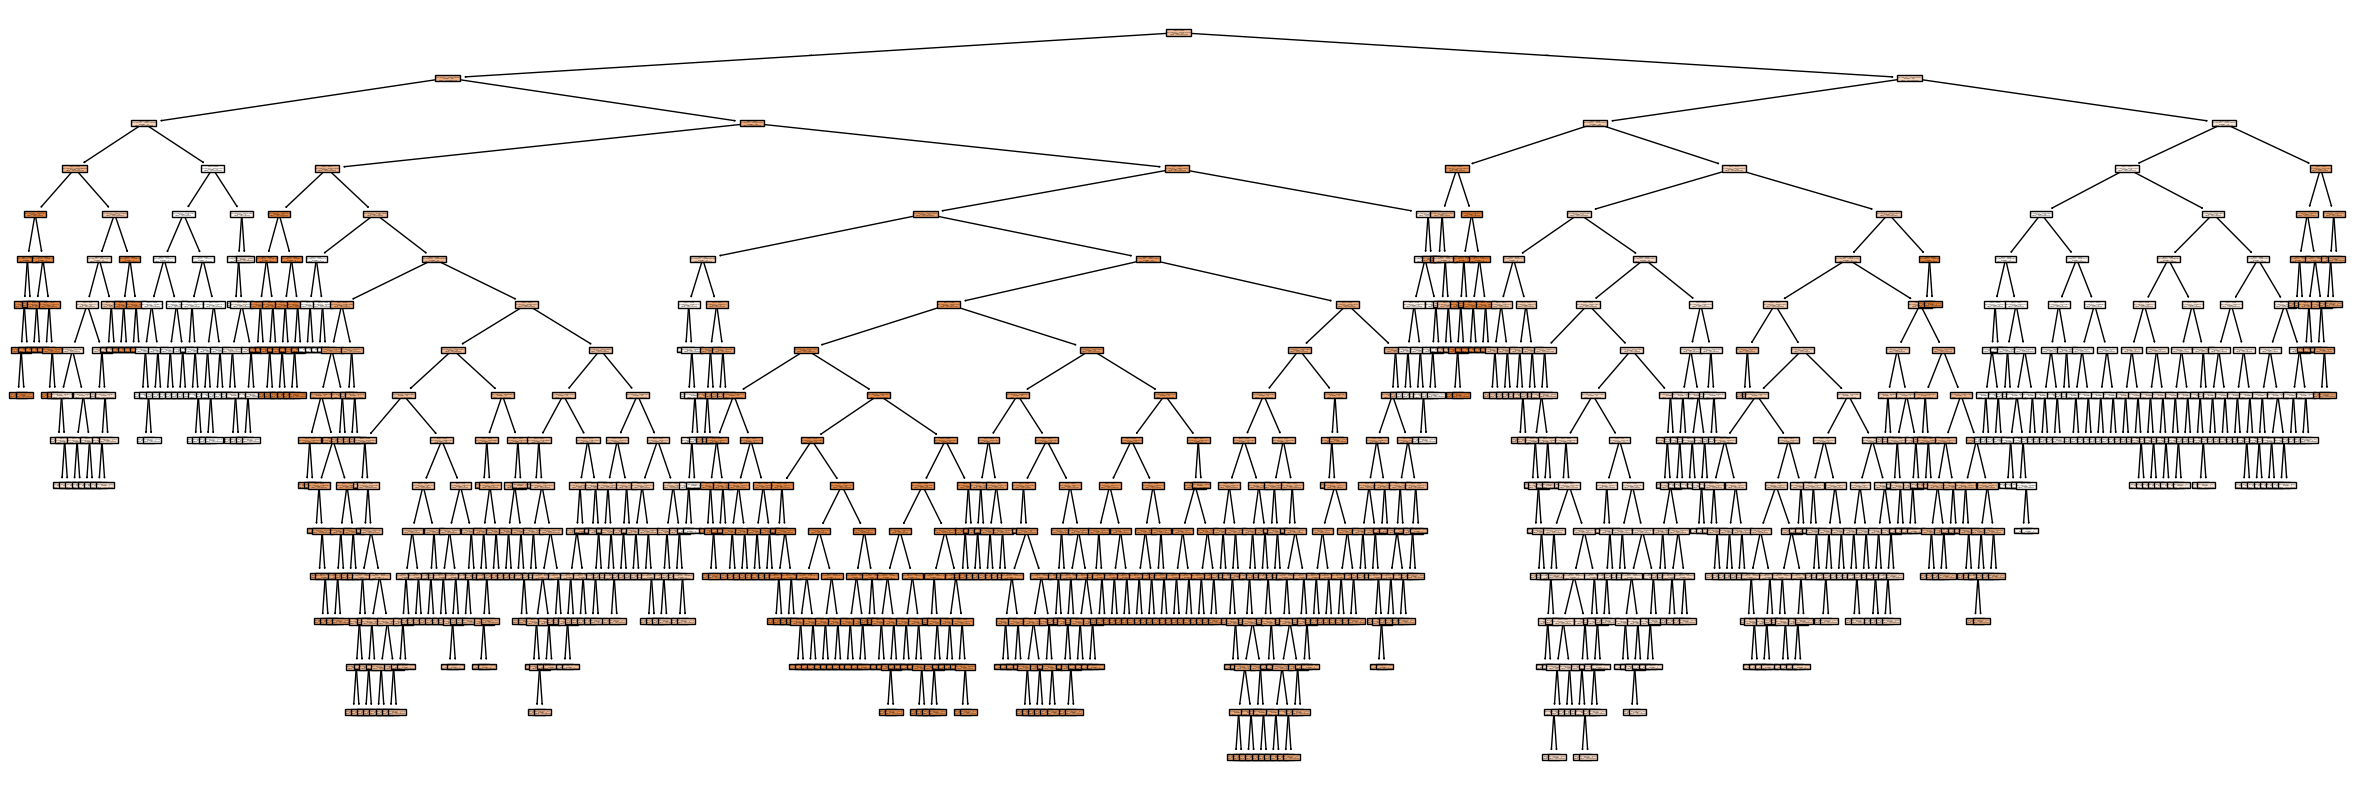

In [ ]:
#imprimir arvore de decisao
plt.figure(figsize=(30, 10))
plot_tree(tree_le, filled=True, feature_names=X_le_train.columns.tolist(), class_names=["0", "1"])
plt.show()

In [ ]:
#impotancias das variaveis
feature_importance=pd.Series(tree_le.feature_importances_, index=X_le_train.columns)
feature_importance=feature_importance.sort_values(ascending=False)
print(feature_importance)


PE4    0.340963
TP1    0.220668
TP2    0.141698
FM1    0.128438
PE1    0.062743
PE2    0.055693
PE3    0.049797
dtype: float64


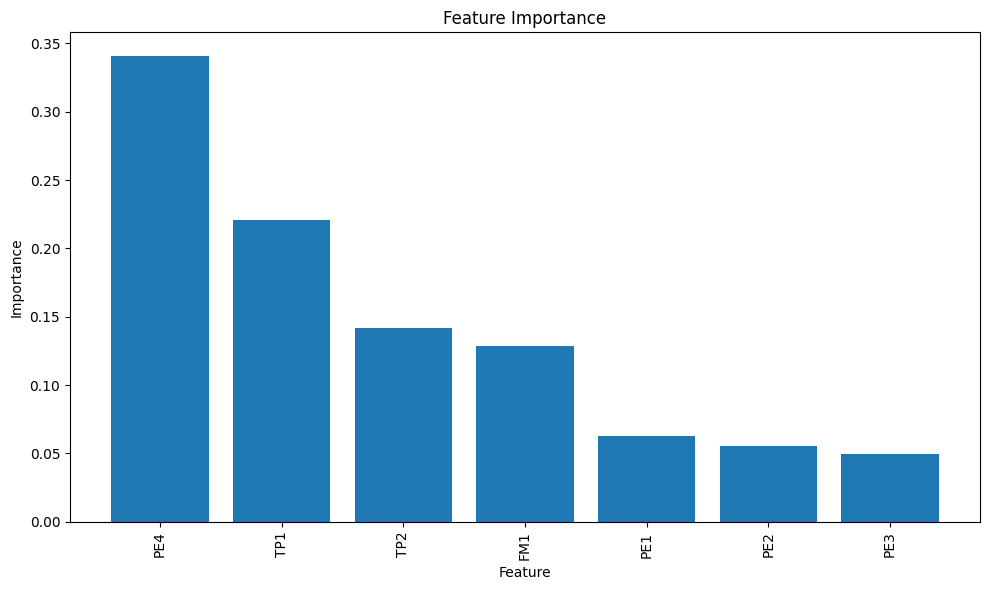

In [ ]:
#grafico da importancia das variaveis
plt.figure(figsize=(10, 6))
feature_importance_df = feature_importance.reset_index()
feature_importance_df.columns = ['Feature', 'Importance']
plt.bar(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.xticks(rotation=90) # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

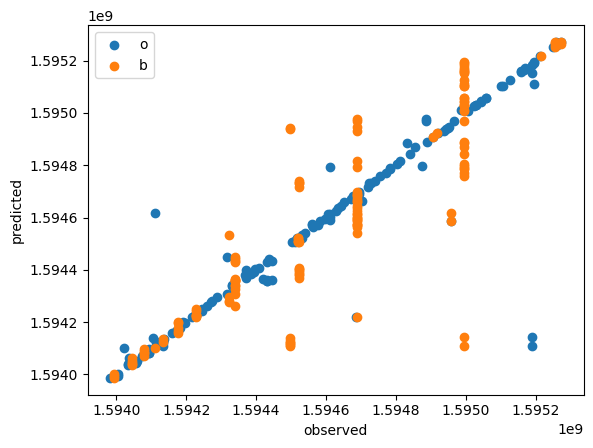

In [ ]:
#plotar o grafico
plt.scatter(y_le_pred, y_le_val, label="LE")
plt.scatter(y_one_pred, y_one_val, label="ONE")
plt.xlabel("observed")
plt.ylabel("predicted")
plt.legend("observed vs predicted")
plt.show()

In [ ]:
#criar e treinar o modelo RandomForest
rf_le=RandomForestRegressor(n_estimators=100, random_state=42)
rf_le.fit(X_le_train, y_le_train)

RandomForestRegressor(random_state=42)

In [ ]:
#fazer predicoes
y_le_pred_rf=rf_le.predict(X_le_val)


In [ ]:
#avaliar as numericas
mse_rf_le=mean_squared_error(y_le_val, y_le_pred_rf)
r2_rf_le=r2_score(y_le_val, y_le_pred_rf)

In [ ]:
#calculo da importancia
feature_importance_rf=pd.Series(rf_le.feature_importances_, index=X_le_train.columns)
feature_importance_rf=feature_importance_rf.sort_values(ascending=False)
print(feature_importance_rf)

PE4    0.325462
FM1    0.167569
TP2    0.157481
TP1    0.154638
PE3    0.094498
PE1    0.071828
PE2    0.028524
dtype: float64


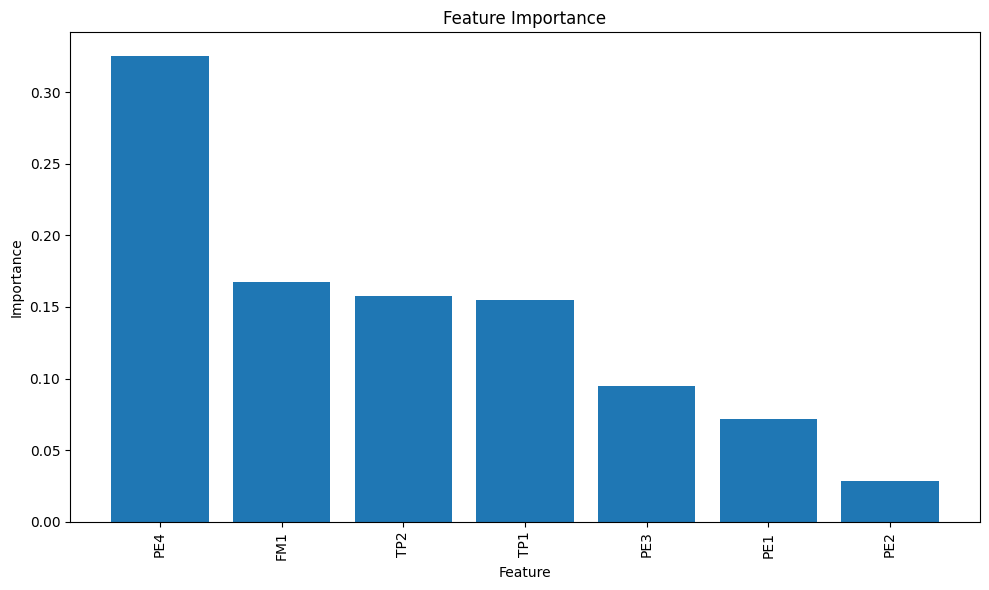

In [ ]:
#grafico da importancia das variaveis
plt.figure(figsize=(10, 6))
feature_importance_rf_df = feature_importance_rf.reset_index()
feature_importance_rf_df.columns = ['Feature', 'Importance']
plt.bar(feature_importance_rf_df["Feature"], feature_importance_rf_df["Importance"])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.xticks(rotation=90) # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

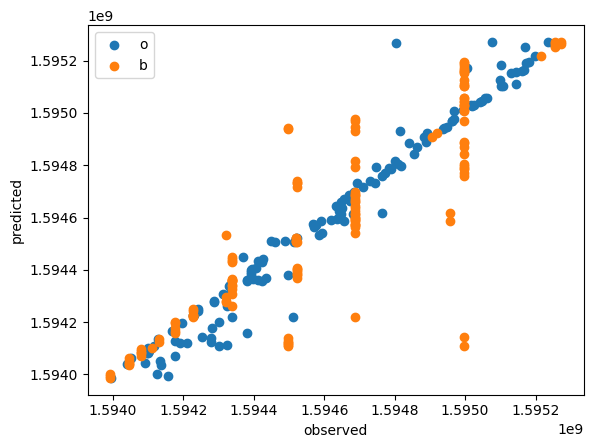

In [ ]:
#plotar o grafico
plt.scatter(y_le_pred_rf, y_le_val, label="LE")
plt.scatter(y_one_pred, y_one_val, label="ONE")
plt.xlabel("observed")
plt.ylabel("predicted")
plt.legend("observed vs predicted")
plt.show()

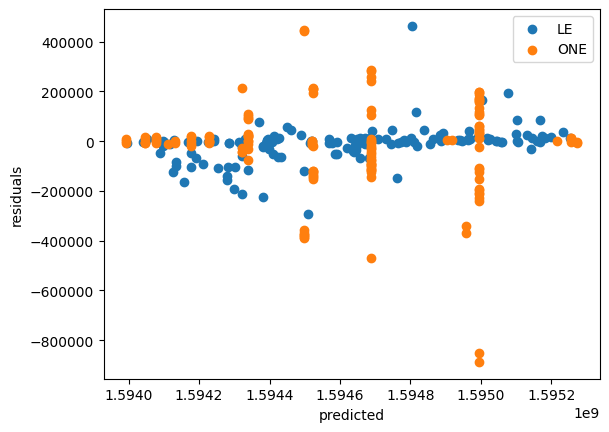

In [ ]:
#plotar graficos dos residuos
residuals_le=y_le_val-y_le_pred_rf
residuals_one=y_one_val-y_one_pred
plt.scatter(y_le_pred_rf, residuals_le, label="LE")
plt.scatter(y_one_pred, residuals_one, label="ONE")
plt.xlabel("predicted")
plt.ylabel("residuals")
plt.legend()
plt.show()

In [ ]:
#CITAR E TREINAR
et_le=ExtraTreesRegressor(n_estimators=100, random_state=42)
et_le.fit(X_le_train, y_le_train)

ExtraTreesRegressor(random_state=42)

In [ ]:
#realizar as predicoes
y_le_pred_et=et_le.predict(X_le_val)


In [ ]:
#avaliar o modelo
mse_et_le=mean_squared_error(y_le_val, y_le_pred_et)
r2_et_le=r2_score(y_le_val, y_le_pred_et)

In [ ]:
#clculara importancia
feature_importance_rf=pd.Series(rf_le.feature_importances_, index=X_le_train.columns)
feature_importance_rf=feature_importance_rf.sort_values(ascending=False)
print(feature_importance_rf)

PE4    0.325462
FM1    0.167569
TP2    0.157481
TP1    0.154638
PE3    0.094498
PE1    0.071828
PE2    0.028524
dtype: float64


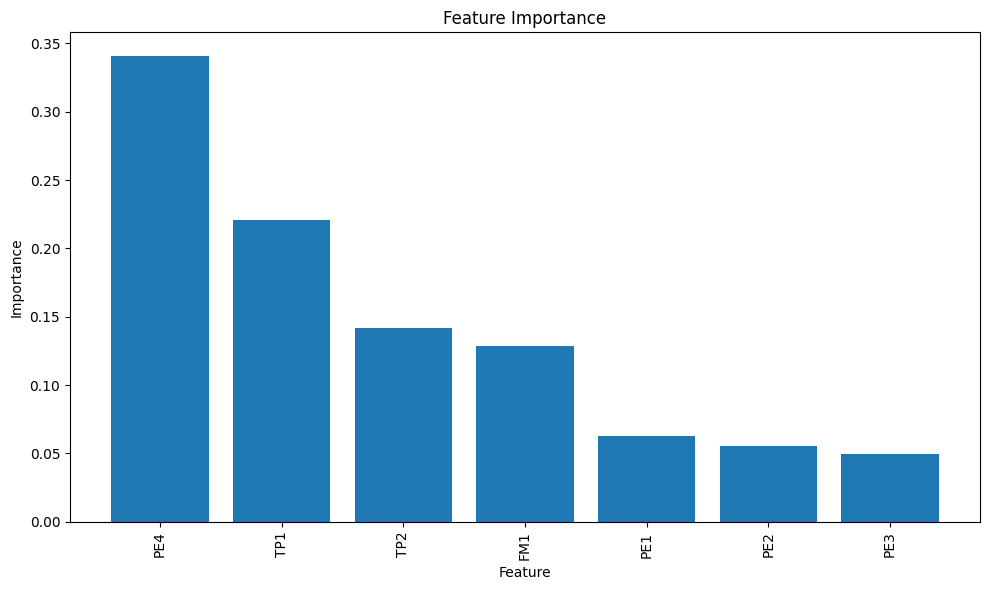

In [ ]:
#grafico da importancia das variaveis
plt.figure(figsize=(10, 6))
feature_importance_et_df = feature_importance.reset_index()
feature_importance_et_df.columns = ['Feature', 'Importance']
plt.bar(feature_importance_et_df["Feature"], feature_importance_et_df["Importance"])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.xticks(rotation=90) # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

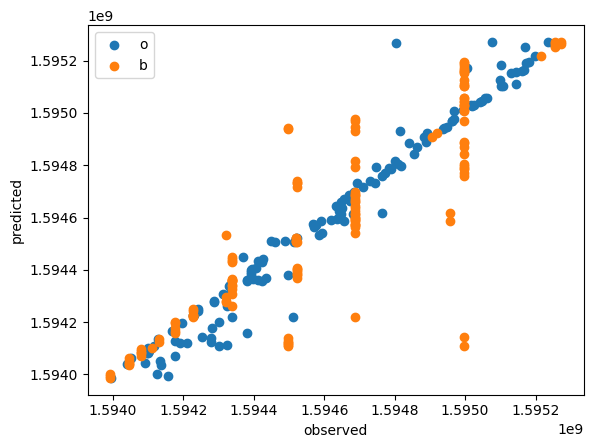

In [ ]:
#plotar o grafico
plt.scatter(y_le_pred_rf, y_le_val, label="LE")
plt.scatter(y_one_pred, y_one_val, label="ONE")
plt.xlabel("observed")
plt.ylabel("predicted")
plt.legend("observed vs predicted")
plt.show()

In [ ]:
#criar e treinar xgboost
gb_le=GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_le.fit(X_le_train, y_le_train)

GradientBoostingRegressor(random_state=42)

In [ ]:
#fazer predicoes
y_le_pred_et=et_le.predict(X_le_val)

In [ ]:
#avaliar metricas
mse_et_le=mean_squared_error(y_le_val, y_le_pred_et)
r2_et_le=r2_score(y_le_val, y_le_pred_et)
print (f"MSE: {mse_et_le}")
print (f"R2: {r2_et_le}")

MSE: 1480900117.7013888
R2: 0.9893162183056684


In [ ]:
#criar e treinar xgboostregression
xgb_le=xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb_le.fit(X_le_train, y_le_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#fazer as predicoes
y_le_pred_xgb=xgb_le.predict(X_le_val)

In [ ]:
#avaliar metrica
mse_xgb_le=mean_squared_error(y_le_val, y_le_pred_xgb)
r2_xgb_le=r2_score(y_le_val, y_le_pred_xgb)